<a href="https://www.kaggle.com/code/yanakutyshenko/notebookcf4f84bd6d?scriptVersionId=355835890" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
import os

data_dir = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train"

classes = os.listdir(data_dir)

print("Кількість класів:", len(classes))
print("Класи:")

for class_name in classes:
    print(class_name)

Кількість класів: 33
Класи:
Orange
Tomato
Passion Fruit
Cucumber Ripe
Cactus fruit
Pomegranate
Plum
Pineapple
Papaya
Potato Red
Kiwi
Limes
Apple Braeburn
Pear
Onion White
Strawberry
Grape Blue
Blueberry
Apple Granny Smith
Apricot
Pepper Red
Clementine
Lemon
Avocado
Raspberry
Cantaloupe
Peach
Corn
Banana
Cherry
Pepper Green
Watermelon
Mango


In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [4]:
from torchvision.datasets import ImageFolder

full_dataset = ImageFolder(
    root=data_dir,
    transform=train_transform
)

print("Кількість зображень:", len(full_dataset))
print("Класи:", full_dataset.classes)

Кількість зображень: 16854
Класи: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


In [5]:
from torch.utils.data import random_split

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size]
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 13483
Test: 3371


In [6]:
print("Назви класів:")

for i, class_name in enumerate(full_dataset.classes):
    print(i, "-", class_name)

Назви класів:
0 - Apple Braeburn
1 - Apple Granny Smith
2 - Apricot
3 - Avocado
4 - Banana
5 - Blueberry
6 - Cactus fruit
7 - Cantaloupe
8 - Cherry
9 - Clementine
10 - Corn
11 - Cucumber Ripe
12 - Grape Blue
13 - Kiwi
14 - Lemon
15 - Limes
16 - Mango
17 - Onion White
18 - Orange
19 - Papaya
20 - Passion Fruit
21 - Peach
22 - Pear
23 - Pepper Green
24 - Pepper Red
25 - Pineapple
26 - Plum
27 - Pomegranate
28 - Potato Red
29 - Raspberry
30 - Strawberry
31 - Tomato
32 - Watermelon


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 422
Test batches: 106


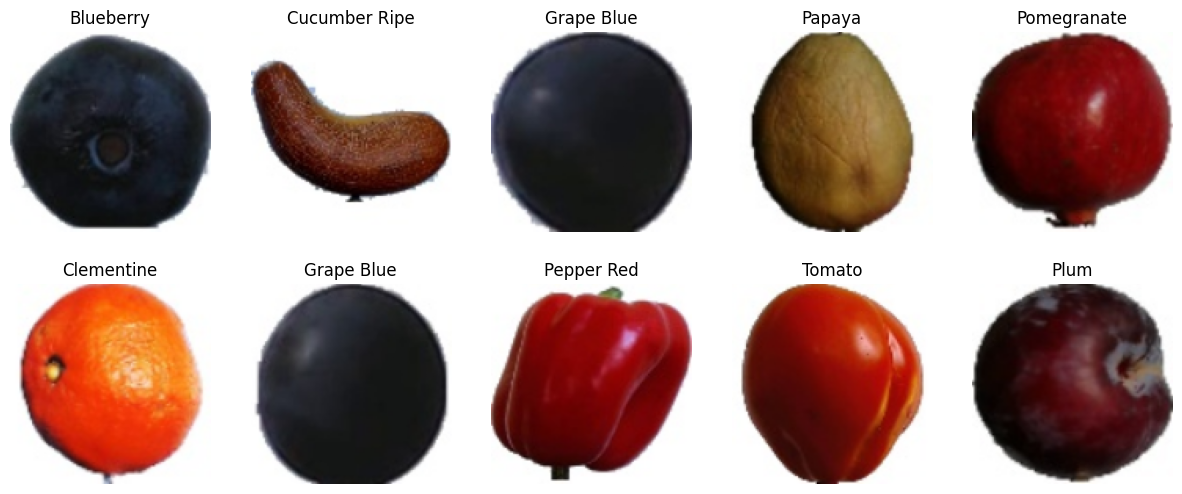

In [8]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(full_dataset.classes[labels[i]])
    ax.axis("off")

plt.show()